# Fintech Churn Intelligence: Exploratory Data Analysis (EDA)

**Objective**
Explore customer churn patterns across demographic, financial, and behavioral variables to understand *who* is churning and *where* the retention team should focus, before any modeling is attempted.

**Dataset:** `Churn_Modelling.csv` — 10,000 bank customers, 14 columns, binary target `Exited` (1 = churned).

**Business Question:** Why are customers leaving the platform, and which customer segments contribute most to churn?

**Notebook Structure**
1. Data Loading & Quality Check
2. Target Variable — Churn Distribution
3. Churn by Geography
4. Churn by Gender
5. Churn by Age
6. Churn by Number of Products
7. Churn by Account Activity Status
8. Correlation Heatmap
9. Key EDA Findings & Handoff


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


## 1. Data Loading & Quality Check

We drop identifier columns (`RowNumber`, `CustomerId`, `Surname`) since they are unique per customer and carry no predictive or analytical signal. We also confirm there are no missing values or duplicate rows before drawing any conclusions from the data.

In [3]:
df = pd.read_csv("/Users/sumitkumargupta/Desktop/1_Project/01_Data/Churn_Modelling.csv")

print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum().sum(), "total missing cells")
print("\nDuplicate rows:", df.duplicated().sum())

df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

df.head()

Shape: (10000, 14)

Missing values:
 0 total missing cells

Duplicate rows: 0


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 2. Target Variable — Churn Distribution

Before looking at any segment, we need a baseline: what fraction of customers churn overall? This number matters for two reasons — it frames every segment comparison that follows, and it foreshadows the class-imbalance problem that the modeling notebook has to explicitly correct for (a model that always predicts "retained" would already be ~80% "accurate" while being useless).

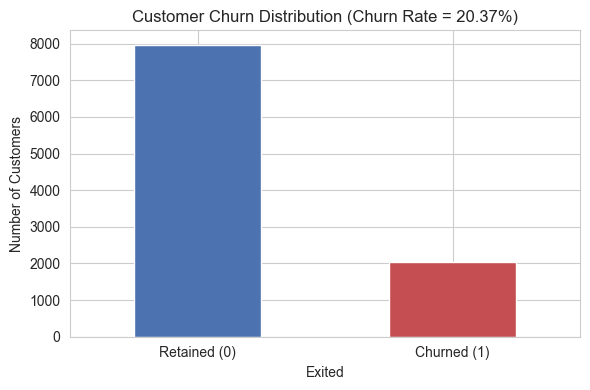

Churned: 2037 customers
Retained: 7963 customers
Churn Rate: 20.37%


In [4]:
churn_rate = df["Exited"].mean()

plt.figure(figsize=(6, 4))
df["Exited"].value_counts().sort_index().plot(
    kind="bar", color=["#4C72B0", "#C44E52"]
)
plt.title(f"Customer Churn Distribution (Churn Rate = {churn_rate:.2%})")
plt.xticks([0, 1], ["Retained (0)", "Churned (1)"], rotation=0)
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

print(f"Churned: {(df['Exited'] == 1).sum()} customers")
print(f"Retained: {(df['Exited'] == 0).sum()} customers")
print(f"Churn Rate: {churn_rate:.2%}")

**Insight:** The overall churn rate is **20.37%** — roughly 1 in 5 customers has left. Out of 10,000 customers, 2,037 churned. This is high enough to be a real retention problem worth investigating segment-by-segment, and imbalanced enough (~80/20) that any model built later must account for class imbalance rather than optimizing for raw accuracy.

## 3. Churn by Geography

We compare churn rate across the three markets in the dataset (France, Germany, Spain) to see whether churn is a company-wide issue or concentrated in a specific region.

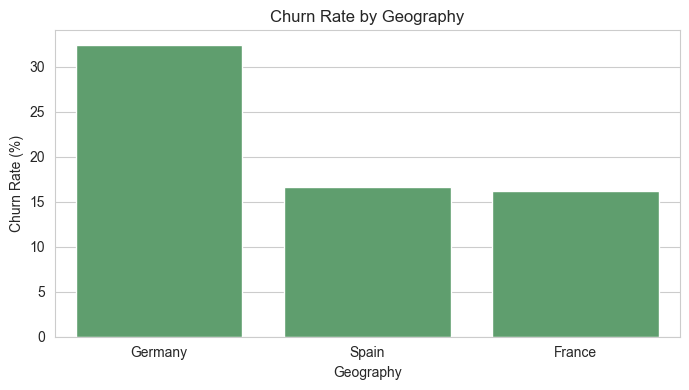

,Total_Customers,Churned_Customers,Churn_Rate
Geography,,,
Germany,2509,814,32.44
Spain,2477,413,16.67
France,5014,810,16.15


In [5]:
geo_churn = df.groupby("Geography")["Exited"].agg(
    Total_Customers="count",
    Churned_Customers="sum",
    Churn_Rate="mean"
).sort_values("Churn_Rate", ascending=False)

geo_churn["Churn_Rate"] = (geo_churn["Churn_Rate"] * 100).round(2)

plt.figure(figsize=(7, 4))
sns.barplot(x=geo_churn.index, y=geo_churn["Churn_Rate"], color="#55A868")
plt.title("Churn Rate by Geography")
plt.xlabel("Geography")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

geo_churn

**Insight:** Germany's churn rate (**32.4%**) is roughly double that of France (16.2%) and Spain (16.7%), despite Germany not having the largest customer base. This points to a geography-specific retention issue — pricing, competition, or service quality in the German market — rather than a uniform, company-wide problem. This is the first candidate for a targeted retention intervention.

## 4. Churn by Gender

We check whether churn differs by gender, since demographic-targeted retention messaging is only worth building if the gap is meaningful.

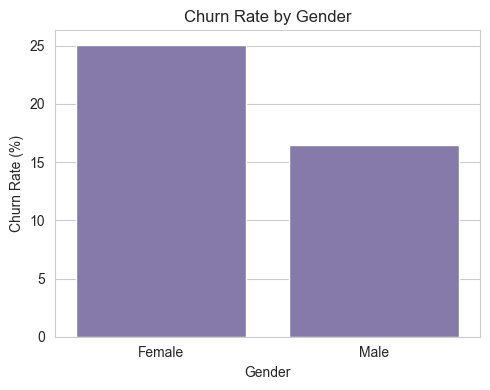

,Total_Customers,Churned_Customers,Churn_Rate
Gender,,,
Female,4543,1139,25.07
Male,5457,898,16.46


In [6]:
gender_churn = df.groupby("Gender")["Exited"].agg(
    Total_Customers="count",
    Churned_Customers="sum",
    Churn_Rate="mean"
).sort_values("Churn_Rate", ascending=False)

gender_churn["Churn_Rate"] = (gender_churn["Churn_Rate"] * 100).round(2)

plt.figure(figsize=(5, 4))
sns.barplot(x=gender_churn.index, y=gender_churn["Churn_Rate"], color="#8172B2")
plt.title("Churn Rate by Gender")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

gender_churn

**Insight:** Female customers churn at **25.1%** versus **16.5%** for male customers — a meaningful ~8.5 point gap. It's a smaller effect than geography, but large enough to be worth including as a model feature and worth a secondary look (e.g. whether it interacts with geography or product holdings) rather than dismissing as noise.

## 5. Churn by Age

Age is checked two ways: as a continuous trend (to see the overall shape of the relationship) and as binned groups (to get a cleaner, business-readable segment view).

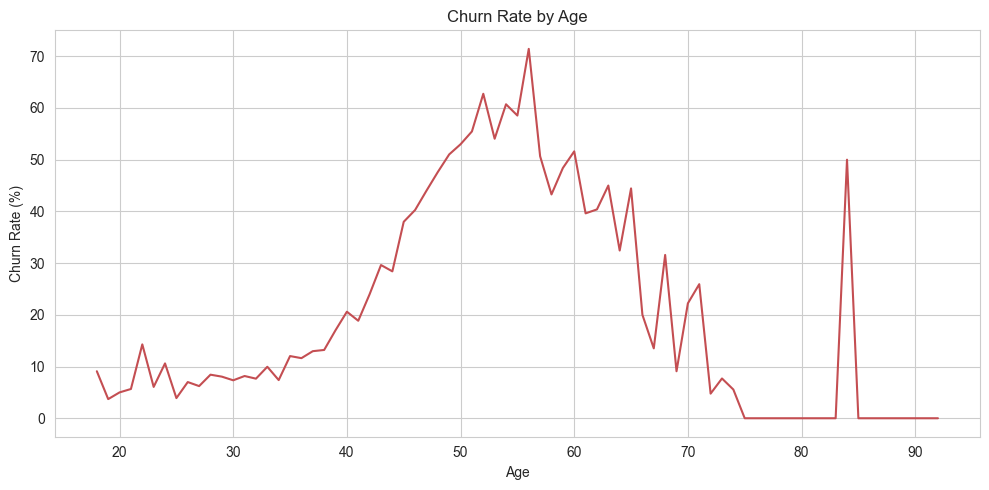

In [7]:
age_churn = df.groupby("Age")["Exited"].mean() * 100

plt.figure(figsize=(10, 5))
plt.plot(age_churn.index, age_churn.values, color="#C44E52")
plt.title("Churn Rate by Age")
plt.xlabel("Age")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

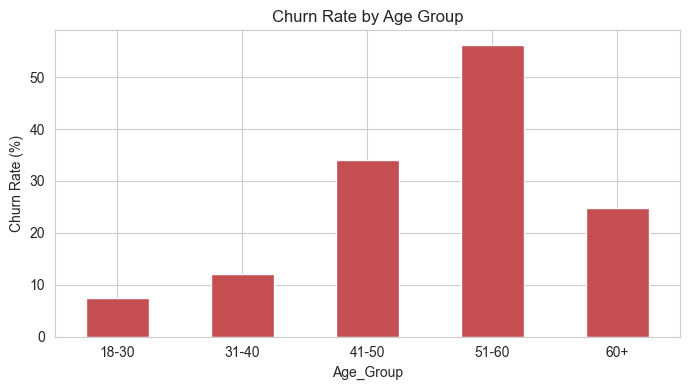

Age_Group
18-30     7.50
31-40    12.09
41-50    33.97
51-60    56.21
60+      24.78
Name: Exited, dtype: float64

In [8]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[18, 30, 40, 50, 60, 100],
    labels=["18-30", "31-40", "41-50", "51-60", "60+"]
)

age_group_churn = (df.groupby("Age_Group", observed=True)["Exited"].mean() * 100).round(2)

age_group_churn.plot(kind="bar", figsize=(7, 4), color="#C44E52")
plt.title("Churn Rate by Age Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

age_group_churn

**Insight:** Churn rises sharply with age through mid-life and peaks at **56.2%** in the 51-60 group — nearly 3x the overall rate — before dropping off for 60+ customers (likely a smaller, different cohort, e.g. long-tenured or already-retired customers). Customers aged 41-60 should be treated as a high-risk retention segment, not the youngest or oldest customers, which contradicts a naive "younger customers churn more" assumption.

## 6. Churn by Number of Products

Product count is a proxy for how embedded a customer is in the platform. We check whether cross-selling more products correlates with retention, and whether that relationship is monotonic.

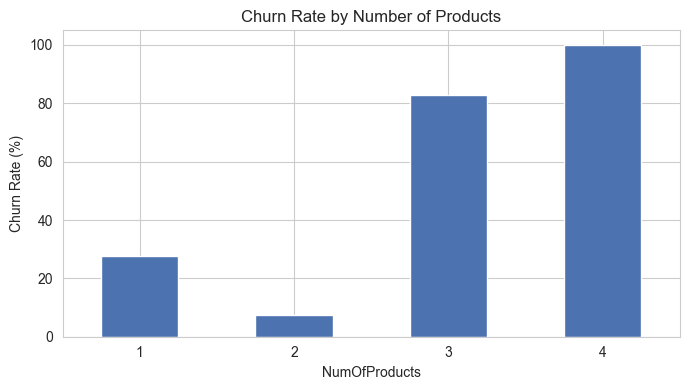

NumOfProducts
1     27.71
2      7.58
3     82.71
4    100.00
Name: Exited, dtype: float64

In [9]:
product_churn = (df.groupby("NumOfProducts")["Exited"].mean() * 100).round(2)

product_churn.plot(kind="bar", figsize=(7, 4), color="#4C72B0")
plt.title("Churn Rate by Number of Products")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

product_churn

**Insight:** The relationship is **not** monotonic, which is the most important and counter-intuitive finding in this notebook. Customers with 2 products churn least (7.6%), but customers with 3 products churn at 82.7% and customers with 4 products churn at 100%. Product count alone is not "more is better" — 3-4 product holders look like a distinct, near-total-churn segment (likely tied to a specific past product bundle, pricing tier, or onboarding cohort) and deserve root-cause investigation before any blanket "cross-sell more products" recommendation is made.

## 7. Churn by Account Activity Status

`IsActiveMember` is a behavioral engagement flag. We check whether inactivity is a leading indicator of churn, since — unlike geography or age — it's something the business can directly act on through re-engagement campaigns.

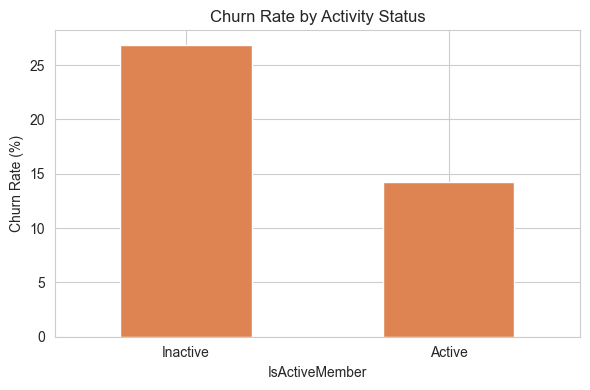

IsActiveMember
0    26.85
1    14.27
Name: Exited, dtype: float64

In [10]:
active_churn = (df.groupby("IsActiveMember")["Exited"].mean() * 100).round(2)

active_churn.plot(kind="bar", figsize=(6, 4), color="#DD8452")
plt.title("Churn Rate by Activity Status")
plt.ylabel("Churn Rate (%)")
plt.xticks([0, 1], ["Inactive", "Active"], rotation=0)
plt.tight_layout()
plt.show()

active_churn

**Insight:** Inactive members churn at **26.9%** versus **14.3%** for active members — roughly double. Unlike age or geography, engagement is directly actionable: re-activation campaigns (app nudges, targeted offers, relationship-manager outreach) are a lower-cost lever than trying to change a customer's age or location.

## 8. Correlation Heatmap

A quick check across all numeric features to spot any strong linear relationships or redundant features before handing this dataset off to modeling.

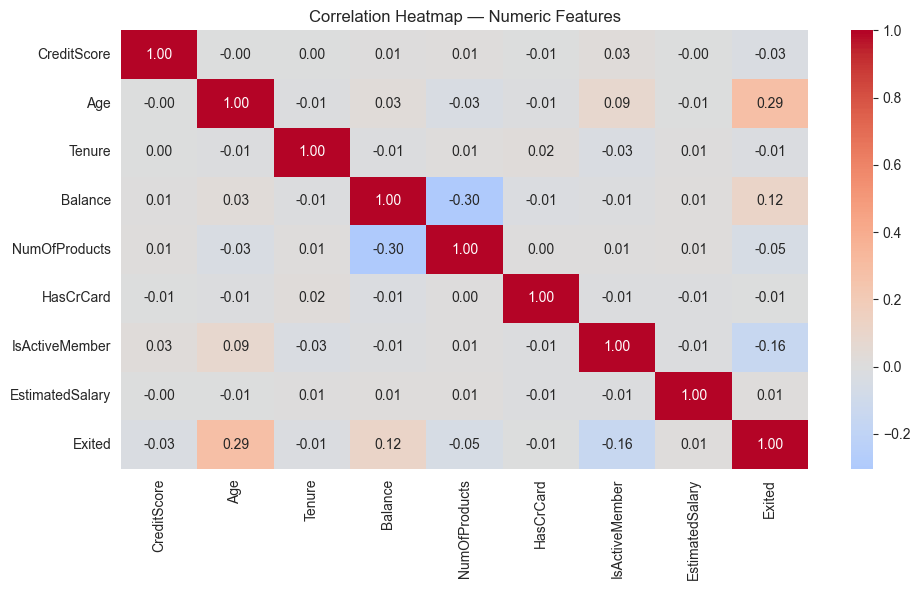

In [11]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    center=0
)
plt.title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.show()

**Insight:** No pair of features is strongly collinear (all correlations are weak-to-moderate), so multicollinearity isn't a concern for the linear model built downstream. `Age` shows the strongest (still moderate) correlation with `Exited`, consistent with the age-group finding above — everything else, including `Balance` and `IsActiveMember`, correlates only weakly with churn on its own. This is expected: churn here looks driven by *segment interactions* (e.g. Germany + 51-60 + inactive) rather than any single linear driver, which is exactly what the cohort-analysis notebook investigates next.

## 9. Key EDA Findings & Handoff

**Summary of findings:**
1. Overall churn rate is 20.37% — imbalanced enough that modeling must correct for it (`class_weight="balanced"`, not raw accuracy).
2. **Germany** churns at 32.4%, roughly double France/Spain — geography is a strong candidate feature and a real regional retention problem.
3. **Age 51-60** is the highest-risk age band (56.2% churn), not the youngest or oldest customers.
4. **3-4 product holders** churn at 83-100% — a small but extreme segment that needs root-cause investigation, not more cross-selling.
5. **Inactive members** churn at nearly 2x the rate of active members (26.9% vs 14.3%) and are the most directly actionable lever.
6. No strong linear collinearity between numeric features — churn appears driven by segment *combinations*, not single variables.

**Where this goes next:**
- `02_cohort_analysis.ipynb` cross-tabulates these segments (e.g. Geography × Age Group) to find the highest-risk *combinations*, not just single-variable effects.
- `03_churn_model.ipynb` builds, tunes, and validates a predictive model on top of these features, with SHAP-based explainability tying back to these same drivers.


---
### Interview Talking Points

- **Why drop `RowNumber`, `CustomerId`, `Surname` immediately?** They are unique identifiers with no repeating pattern for a model to learn from — keeping them risks the model overfitting to noise (e.g. memorizing row order) rather than learning generalizable churn signal.
- **Why check duplicates and missing values before any analysis?** Any segment-level churn rate computed on a dataset with hidden duplicates or nulls would be silently wrong; it's a five-second check that protects every conclusion drawn afterward.
- **Why look at single-variable segments before modeling?** EDA sets a human-interpretable baseline. If a model later says "age doesn't matter," that's a red flag worth investigating — EDA is the ground truth I check model behavior against.
- **Why report percentages and raw counts together?** A 100% churn rate on 4 customers is not the same finding as 100% on 400 — showing both lets a stakeholder judge whether a segment is worth acting on.
- **Why flag the non-monotonic `NumOfProducts` relationship instead of just reporting it?** Because it's counter-intuitive and easy to misread as "cross-sell more products" when the data actually says the opposite for 3-4 products — calling that out explicitly prevents a wrong business recommendation.
